In [3]:
# Basic Probability

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import random


In [4]:
# Coin Flips: The Bernoulli Distribution

# Let's start by considering the so-called Bernoulli distribution. It's a great way to think about coin flips.
    # There are only two possible events: the flip comes out heads, or it comes out tails.
    # If we run this process a lot of times, we can observe the frequency of heads and tails.

# flip a fair coin
random.seed(42)
random.random() > 0.5

True

In [5]:
# flip a fair coin 20 times
[random.random() > 0.5 for _ in range(20)]

[False,
 False,
 False,
 True,
 True,
 True,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 True,
 True,
 False,
 True,
 True,
 False,
 True]

In [6]:
# Using the scipy library
# The scipy library has built-in functions for making multiple random draws from many distributions, including Bernoulli. 
# The implementation of bernouuli has 0 and 1 as the two possible events, rather than True and False With p, the probability 
# of success (1) as the only parameter.

from scipy.stats import bernoulli

np.random.seed(42)
draws = bernoulli.rvs(p=0.5, size=20)  # Generate the random draws

# Create a pandas DataFrame
df = pd.DataFrame(draws, columns=["Outcome"])
df

,Outcome
0,0
1,1
2,1
3,1
4,0
5,0
6,0
7,1
8,1
9,1


In [7]:
# compute the frequency of each outcome
df["Outcome"].value_counts()

Outcome
0    11
1     9
Name: count, dtype: int64

In [8]:
# Let's draw a much larger sample
draws = bernoulli.rvs(p=0.5, size=100000)
df = pd.DataFrame(draws, columns=["Outcome"])
df["Outcome"].value_counts()

Outcome
1    50067
0    49933
Name: count, dtype: int64

In [9]:
# The .value_counts method has a normalize parameter that can be set to True to compute the relative frequencies (i.e., probabilities)
# (Note that probabilities are always between 0 and 1, and they sum to 1.)

df["Outcome"].value_counts(normalize=True)

Outcome
1    0.50067
0    0.49933
Name: proportion, dtype: float64

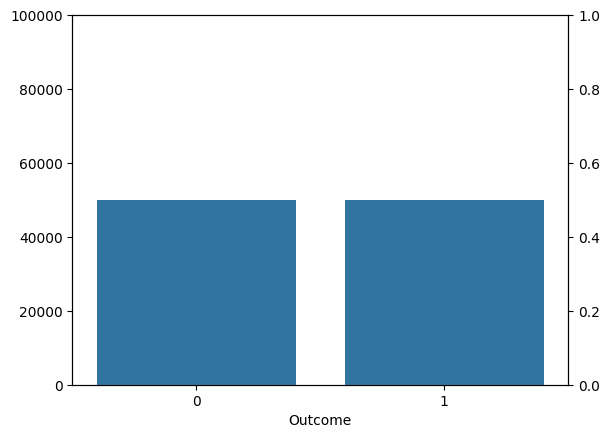

In [10]:
counts = df["Outcome"].value_counts()
freqs = df["Outcome"].value_counts(normalize=True)

# Create a figure and a single subplot
fig, ax1 = plt.subplots()

# Create the bar plot basd on counts
sns.barplot(x=counts.index, y=counts.values, ax=ax1)

# Also show the normalized frequency
# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()
sns.barplot(x=freqs.index, y=freqs.values, ax=ax2)


# Set the maximum value of the y-axes
ax1.set_ylim(0, df.shape[0])  # max is the number of rows
ax2.set_ylim(0, 1)  # 1 is the maximum value a probability can have

# Show the plot
plt.show()

In [11]:
# Let's make a pair of functions to do that work for us. We'll be able to call it repeatedly with slightly different inputs.

def draw_bernoulli(p, n):
    # Generate the random draws
    draws = bernoulli.rvs(p, size=n)
    # Create a pandas DataFrame
    return pd.DataFrame(draws, columns=["Outcome"])

def plot(data, ax1):
    # Get the counts and frequencies
    counts = data["Outcome"].value_counts()
    # Create the bar plot on the first y-axis
    ax1.set_ylim(0, data.shape[0])  # max is the number of rows
    counts = data["Outcome"].value_counts()
    sns.barplot(x=counts.index, y=counts, ax=ax1)
    ax1.set(xlabel=None, ylabel=None)  # Hide x-axis and y-axis legends

    # Plot the normalized frequency on a second y-axis, on the right side
    ax2 = ax1.twinx()
    ax2.set_ylim(0, 1)  # 1 is the maximum value a probability can have
    freqs = data["Outcome"].value_counts(normalize=True)
    sns.barplot(x=freqs.index, y=freqs.values, ax=ax2)
    ax2.set(xlabel=None, ylabel=None)  # Hide x-axis and y-axis legends
    

In [12]:
df = draw_bernoulli(0.25, 100000)
df.head(20)

,Outcome
0,1
1,0
2,0
3,1
4,0
5,0
6,0
7,1
8,0
9,0


In [13]:
df["Outcome"].value_counts()

Outcome
0    74959
1    25041
Name: count, dtype: int64

In [14]:
df["Outcome"].value_counts(normalize=True)

Outcome
0    0.74959
1    0.25041
Name: proportion, dtype: float64

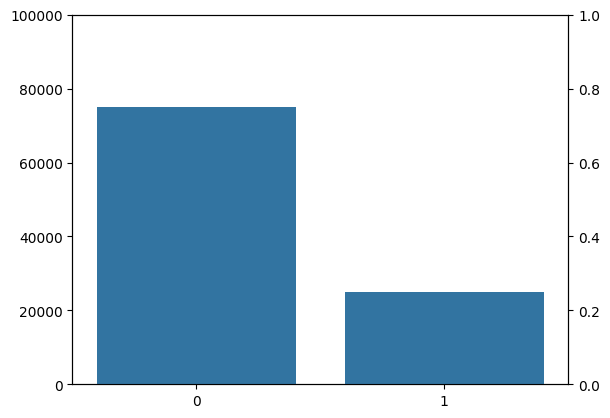

In [15]:
plot(df, plt.gca())

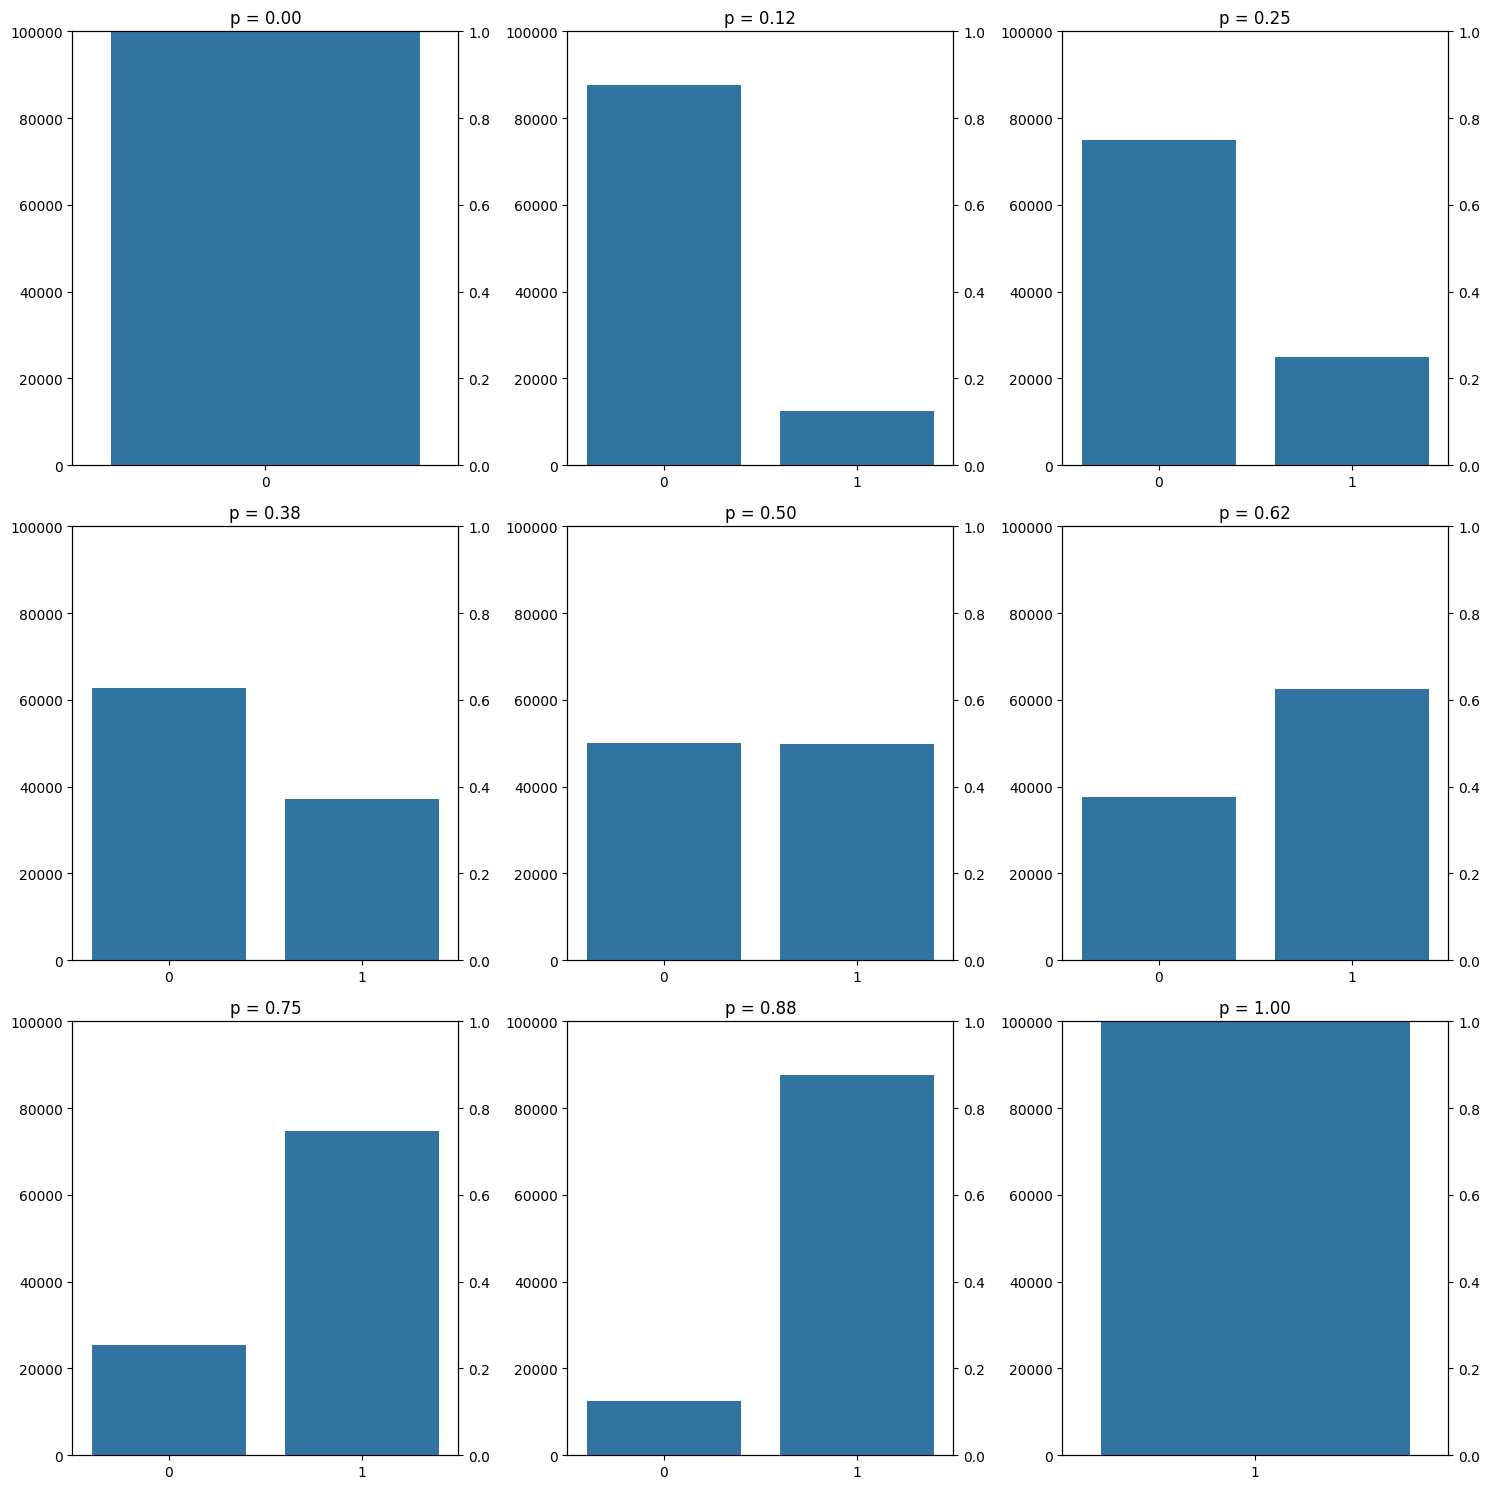

In [16]:
# Now let's generate plots for increasing values of p, and show them as small multiples in a larger plot

# Create a larger figure
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

# Generate the plots
for i, p in enumerate(np.linspace(0, 1, 9)):
    # first three on the first row; column 1 has the first plot, column 2 has the second plot, etc.
    plot(draw_bernoulli(p, 100000), axs[i // 3, i % 3])
    axs[i // 3, i % 3].set_title(f'p = {p:.2f}')  # Add a title indicating the value of p


# Adjust the layout
plt.tight_layout()
# Show the plots
plt.show()

In [17]:
# Other Discrete Distributions
# You've already seen the Bernoulli distribution, with just two possible outcomes, heads or tails, True or False, 0 or 1.
# More generally, a discrete distribution has discrete, or categorical outcomes. Generally, a finite number of possible outcomes. 
# But technically, if we have a countably infinite number of possible outcomes, like all the integers, we still call it a discrete distribution.
# Let's look at some other discrete distributions, with more than two possible outcomes (events).
# We'll follow the same approach of using a data generating function, the distribution, to generate a large sample; and then we'll plot the frequencies.

# Six-sided die¶
# Let's start with a fair die, where each of the sides is equally weighted. Then we'll consider an unfair die.
# Sample data from a discrete distribution with six possible labels, specifying the probability of each label
np.random.seed(42)


def sample_discrete(weights=[1, 1, 1, 1, 1, 1], n=1000, labels=None):
    if not labels:
        labels = range(1, len(weights) + 1)
    probs = weights / np.sum(weights)
    data = np.random.choice(labels, size=n, p=probs)
    df = pd.DataFrame(data, columns=["outcome"])
    df["outcome"] = pd.Categorical(df["outcome"], categories=labels, ordered=True)
    return df



In [18]:
labels = ["one", "two", "three", "four", "five", "six"]
df = sample_discrete(n=20, labels=labels)
df

,outcome
0,three
1,six
2,five
3,four
4,one
5,one
6,one
7,six
8,four
9,five


In [19]:
sample_discrete(n=1000, labels=labels).outcome.value_counts().reindex(labels)

outcome
one      185
two      158
three    156
four     182
five     152
six      167
Name: count, dtype: int64

In [20]:
def plot_discrete(data, ax1):
    # Create the bar plot on the first y-axis
    counts = data["outcome"].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax1)
    # Plot the normalized frequency on a second y-axis
    ax2 = ax1.twinx()
    freqs = data["outcome"].value_counts(normalize=True)
    sns.barplot(x=freqs.index, y=freqs.values, ax=ax2)

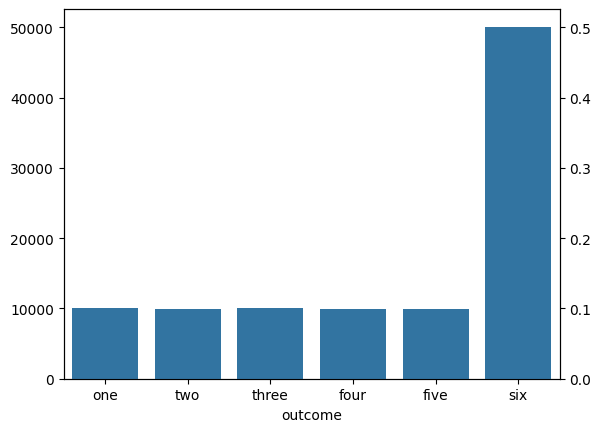

In [21]:
# What happens if we change the weights, trying to make our die come out with a lot more sixes?
plot_discrete(
    sample_discrete(
        weights=np.array([1, 1, 1, 1, 1, 5]),
        n=100000,
        labels=["one", "two", "three", "four", "five", "six"],
    ),
    plt.gca(),
)

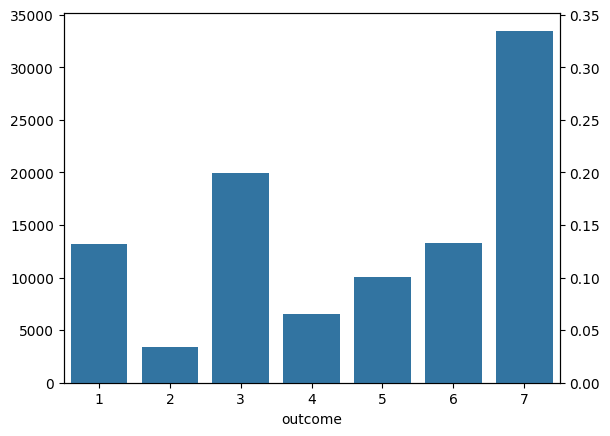

In [22]:
# I can make a seven-sided die just as easily, with whatever weights I want
plot_discrete(
    sample_discrete(weights=np.array([4, 1, 6, 2, 3, 4, 10]), n=100000), plt.gca()
)

In [23]:
# Poisson

# The Poisson distribution is a discrete distribution that models the number of events occurring in a fixed interval of time or space.
    # It is characterized by a single parameter, λ (lambda), which is the average number of events in each interval.
    # The probability of observing k events in an interval is given by the Poisson probability mass function:

# The Poisson distribution is used to model count data, such as the number of emails received in a day, the number of calls received in an hour, 
# or the number of decay events per second from a radioactive source.


# sample from a poisson distribution
def sample_poisson(lam=1, n=1000):
    data = np.random.poisson(lam=lam, size=n)
    return pd.DataFrame(data, columns=["outcome"])


In [24]:
sample_poisson(lam=1, n=20)

,outcome
0,1
1,0
2,0
3,0
4,2
5,1
6,0
7,2
8,0
9,1


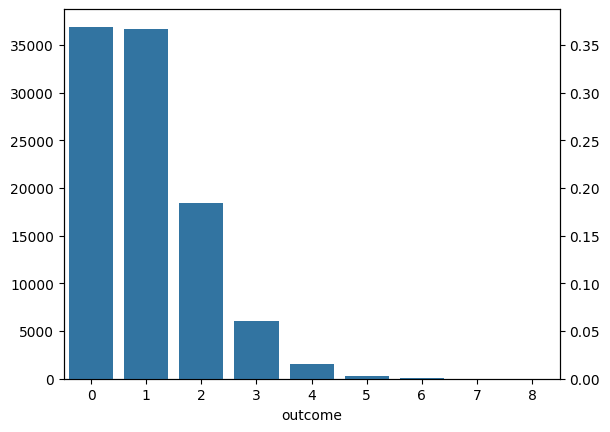

In [25]:
plot_discrete(sample_poisson(lam=1, n=100000), plt.gca())

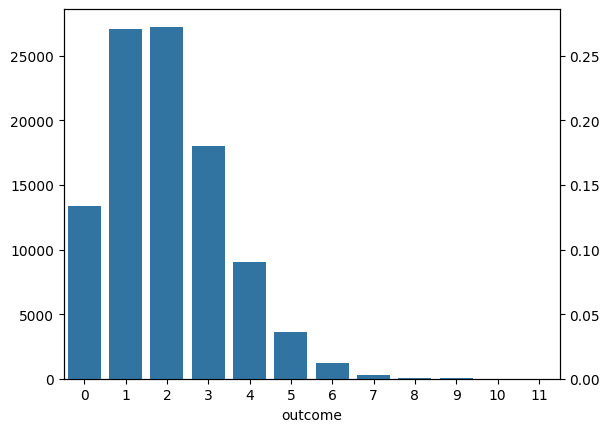

In [26]:
plot_discrete(sample_poisson(lam=2, n=100000), plt.gca())

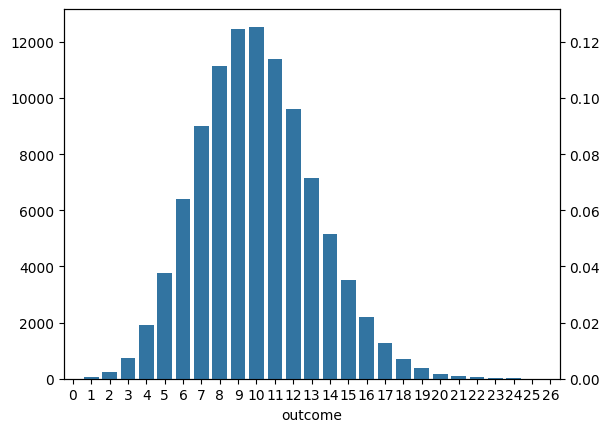

In [27]:
plot_discrete(sample_poisson(lam=10, n=100000), plt.gca())

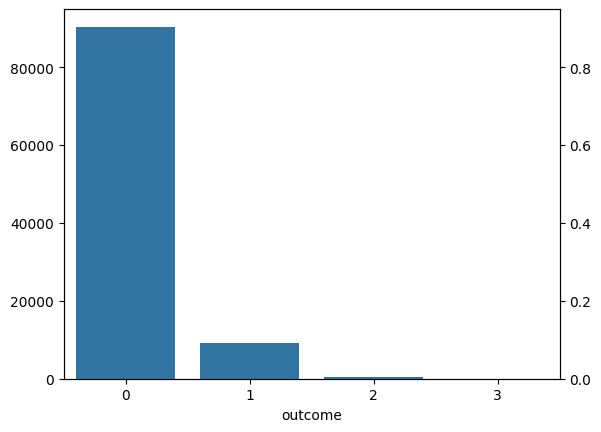

In [28]:
plot_discrete(sample_poisson(lam=1 / 10, n=100000), plt.gca())

In [29]:
# Zipf

# What happens if we count up all the words in a large book? well, some words, like "the" are used extremely often. and some are rare, 
# they only happen once. It turns out that when we plot the usage of words, it often follows something called a Zipf-distribution.

# The zipf distribution has just one parameter, alpha, that controls the distribution of the frequencies. A small alpha results in a 
# distribution with many rare words, while a large alpha results in a distribution with fewer rare words.

def sample_zipf(alpha, n=1000):
    # use the scipy zipf distribution
    data = stats.zipf.rvs(a=alpha, size=n)
    return pd.DataFrame(data, columns=["outcome"])


In [30]:
sample_zipf(alpha=1.5, n=20)

,outcome
0,1
1,1
2,1
3,5
4,123
5,2
6,63
7,2
8,1
9,27


In [31]:
# get counts
df = sample_zipf(alpha=1.5, n=10000)
df["outcome"].value_counts().sort_index()

outcome
1          3818
2          1344
3           779
4           439
5           347
           ... 
466124        1
579538        1
603446        1
969271        1
1626382       1
Name: count, Length: 661, dtype: int64

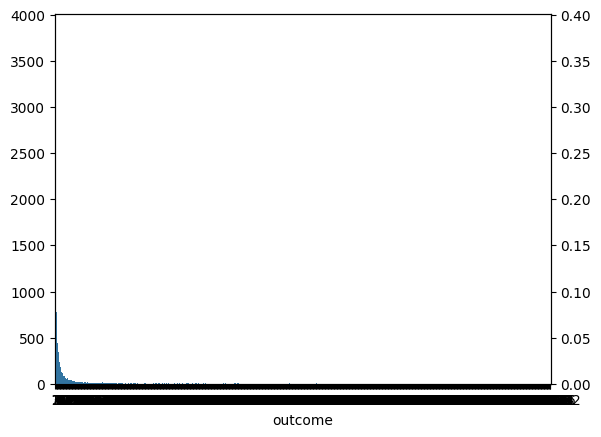

In [32]:
plot_discrete(df, plt.gca())

In [33]:
# Uh-oh, Zipf's law! The distribution is highly skewed, with a few outcomes having very high frequencies. So, we can't see the majority of the data on the plot.
# We're going to need to do a few things:
    # - Set a max-value on the y-axis that is much less than everything.
    # - Use a log scale on the y-axis. That is, instead of plotting the counts, we'll plot the log of the counts.
    # - Use only a few tick marks on the x-axis
    # - relabel the x-axis as ranks, rather than outcomes


def plot_zipf(data, ax1):
    # Create the bar plot on the first y-axis
    counts = data["outcome"].value_counts(ascending=False)
    counts.index = range(1, len(counts) + 1)
    # Use a log scale for the y-axis
    ax1.set_yscale("log")
    # Use a log scale for the x-axis
    sns.barplot(x=counts.index, y=counts, ax=ax1, order=counts.index)
    ticks = np.linspace(1, len(counts), 6, dtype=int)  # Create 6 evenly spaced tick positions
    ax1.set_xticks(ticks)  # Set the x-axis tick positions    
    # retitle the x-axis
    ax1.set_xlabel("Rank")

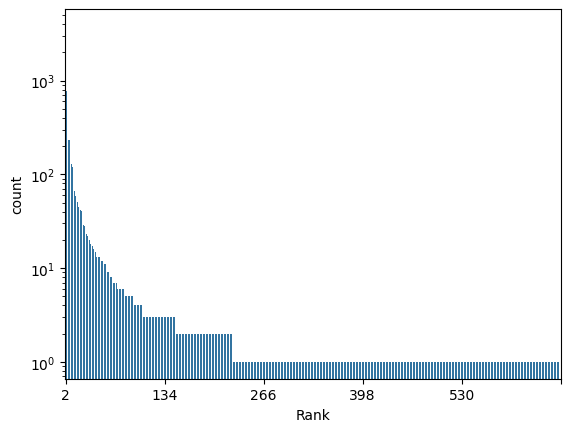

In [34]:
plot_zipf(df, plt.gca())

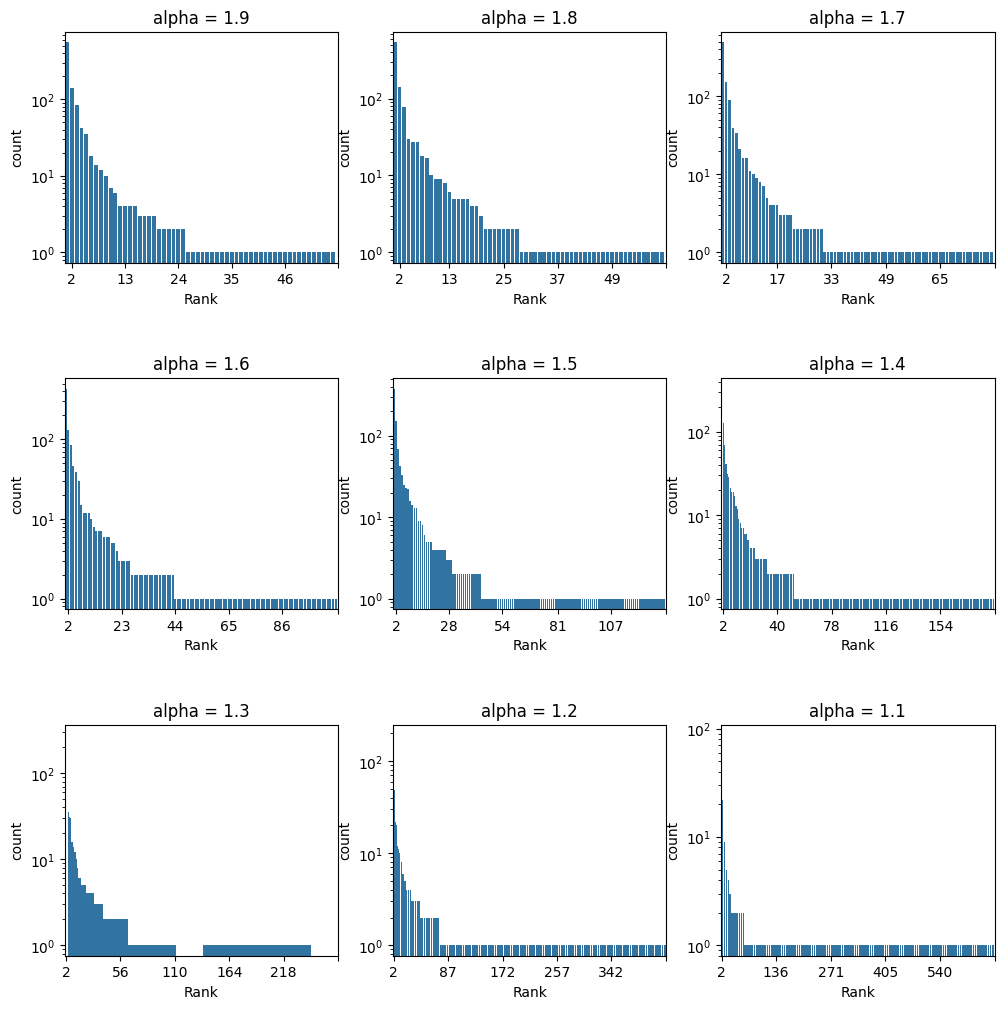

In [35]:
# make small multiple plots with increasing alpha
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
for i, ax in enumerate(axs.ravel()):
    plot_zipf(sample_zipf(alpha=1.9-i/10, n=1000), ax)
    ax.set_title(f"alpha = {(1.9- i/10):.1f}")
plt.subplots_adjust(hspace=0.5)  # Add more space between the subplots

In [ ]:
# Continuous Distributions

# A continuous distribution is just like a discrete one, except the range of possible outcomes is continous instead of having a limited, 
# discrete set of possible outcomes. For example, the possible outcome events might be any floating point number in the range [0,1] or in the range[-inf, +inf]

# Instead of a probability mass function, with the sum of all probabilities adding up to 1, we have a probability density function, 
# with a "density" value for each outcome. And the area under the curve totals 1.

# Mixture of two betas
# Let's start with a bit of a mystery distribution. Most likely you haven't seen a mixture of two beta distributions. But we can investigate it empirically.

# This function creates two distributions, one is left-heavy (closer to zero), and the other is right-heavy (leaning to 1).
def sample_mix_of_two_betas(alpha1=1, beta1=5, alpha2=5, beta2=1, mix=0.5, n=1000):
    which = np.random.choice([1, 2], size=n, p=[mix, 1 - mix])
    b1 = np.random.beta(alpha1, beta1, n)
    b2 = np.random.beta(alpha2, beta2, n)
    df = pd.DataFrame({"outcome": np.where(which == 1, b1, b2)})
    return df

sample_mix_of_two_betas()

,outcome
0,0.658509
1,0.738769
2,0.098752
3,0.995382
4,0.031800
...,...
995,0.252917
996,0.965270
997,0.772941
998,0.874992


In [37]:
data = sample_mix_of_two_betas(n=100000)

# divide into 100 bins and compute counts within each bin
bins = np.arange(0, 1.01, 0.01)  # Creates an array from 0 to 1 with a step of 0.01
data["bin"], bin_ranges = pd.cut(data["outcome"], bins=bins, retbins=True)
data

,outcome,bin
0,0.939239,"(0.93, 0.94]"
1,0.618911,"(0.61, 0.62]"
2,0.392239,"(0.39, 0.4]"
3,0.956039,"(0.95, 0.96]"
4,0.071687,"(0.07, 0.08]"
...,...,...
99995,0.080628,"(0.08, 0.09]"
99996,0.802975,"(0.8, 0.81]"
99997,0.841660,"(0.84, 0.85]"
99998,0.740898,"(0.74, 0.75]"


In [ ]:
counts = data.groupby("bin", observed=False).size() # include those that has zero observation.
counts

bin
(0.0, 0.01]     2520
(0.01, 0.02]    2352
(0.02, 0.03]    2201
(0.03, 0.04]    2228
(0.04, 0.05]    2079
                ... 
(0.95, 0.96]    2075
(0.96, 0.97]    2204
(0.97, 0.98]    2241
(0.98, 0.99]    2332
(0.99, 1.0]     2431
Length: 100, dtype: int64

In [40]:
# normalise
counts / counts.sum()

bin
(0.0, 0.01]     0.02520
(0.01, 0.02]    0.02352
(0.02, 0.03]    0.02201
(0.03, 0.04]    0.02228
(0.04, 0.05]    0.02079
                 ...   
(0.95, 0.96]    0.02075
(0.96, 0.97]    0.02204
(0.97, 0.98]    0.02241
(0.98, 0.99]    0.02332
(0.99, 1.0]     0.02431
Length: 100, dtype: float64

In [41]:
def plot_continuous(
    data, ax1, num_bins=100, label_precision=2, min_val=0, max_val=1, max_prob=None
):
    # Create the bar plot on the first y-axis

    # filter out the data outside the min_val and max_val range
    data = data[(data["outcome"] >= min_val) & (data["outcome"] <= max_val)]

    # define the bin edges
    bin_edges = np.linspace(min_val, max_val, num_bins + 1)
    data["bin"], bin_ranges = pd.cut(data["outcome"], bins=bin_edges, retbins=True)
    counts = data.groupby("bin", observed=False).size()
    probs = counts / counts.sum()
    # use the left edge of each bin_range as the x-axis labels, rounded to the nearest 2 decimal places
    left_edges = bin_ranges[:-1]
    # round the labels to 2 decimal places
    labels = np.round(left_edges, label_precision)

    sns.barplot(x=labels, y=probs, ax=ax1)
    # set maximum probability value if provided
    if max_prob:
        ax1.set_ylim(0, max_prob)

    # Only show every 10th label on the x-axis, for better readability
    for ind, label in enumerate(ax1.get_xticklabels()):
        if ind % 10 == 0:  # every 10th label is kept
            label.set_visible(True)
        else:
            label.set_visible(False)
        # Set y-axis label to "Probability"

    ax1.set_ylabel("Probability")
    

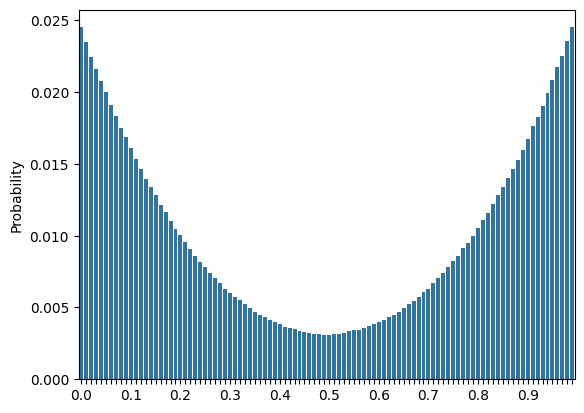

In [50]:
# the following two figures shows Continuous Distribution can come in different shapes.

plot_continuous(sample_mix_of_two_betas(n=5000000), plt.gca())

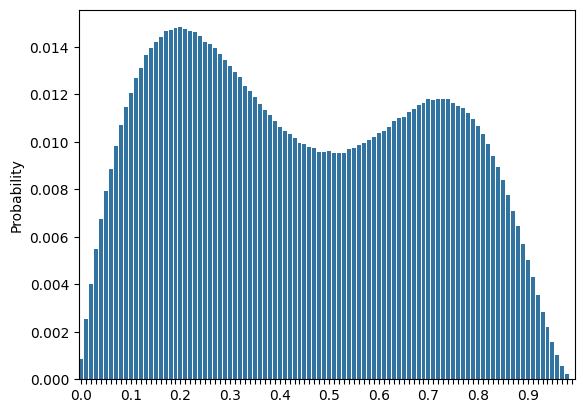

In [43]:
plot_continuous(sample_mix_of_two_betas(2, 5, 7, 3, mix=0.6, n=5000000), plt.gca())

In [ ]:
# Uniform Distribution
#   every possible outcome has the same density

def sample_uniform(low=0.0, high=1.0, n=1000):
    return pd.DataFrame({"outcome": np.random.uniform(low=low, high=high, size=n)})

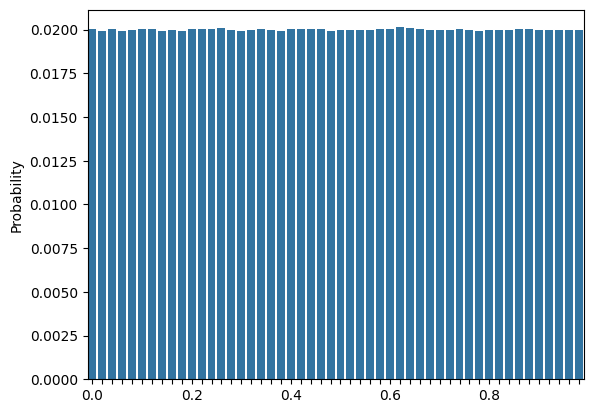

In [45]:
plot_continuous(sample_uniform(n=10000000), plt.gca(), num_bins=50)

In [46]:
sample_uniform(low=1, high=11, n=20)

,outcome
0,3.681406
1,2.826813
2,10.469610
3,2.001144
4,10.903187
5,7.957403
6,4.276795
7,3.251116
8,3.004996
9,5.381842


In [47]:
df = sample_uniform(low=1, high=11, n=10000000)
# output minimum and maximum values of the "outcome" column
df["outcome"].min(), df["outcome"].max()

(np.float64(1.000000122799222), np.float64(10.999999317348815))

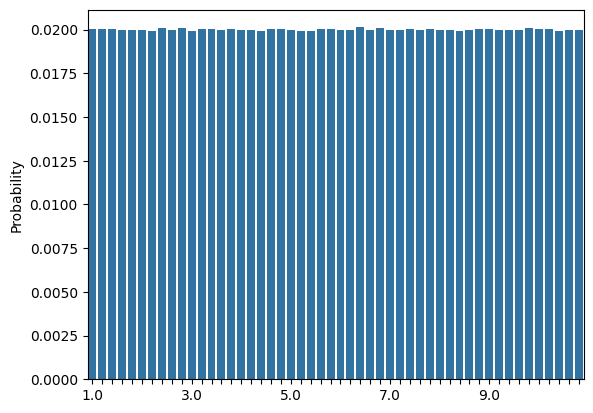

In [48]:
plot_continuous(
    sample_uniform(low=1, high=11, n=10000000),
    plt.gca(),
    num_bins=50,
    min_val=1,
    max_val=11,
)

In [51]:
# Normal distribution
# The normal distribution is also known as the Gaussian distribution. It is characterized by two parameters:
    # The mean μ determines the location of the peak of the distribution and the standard deviation σ determines the width of the distribution.
    # The normal distribution is symmetric about the mean μ.


def sample_normal(mu=0, sigma=1, n=1000):
    return pd.DataFrame({"outcome": np.random.normal(loc=mu, scale=sigma, size=n)})


In [52]:
sample_normal(n=20)

,outcome
0,0.386967
1,-0.409407
2,-0.147119
3,-0.176268
4,-0.513261
5,-0.681604
6,-0.787063
7,-0.033168
8,1.361694
9,0.261849


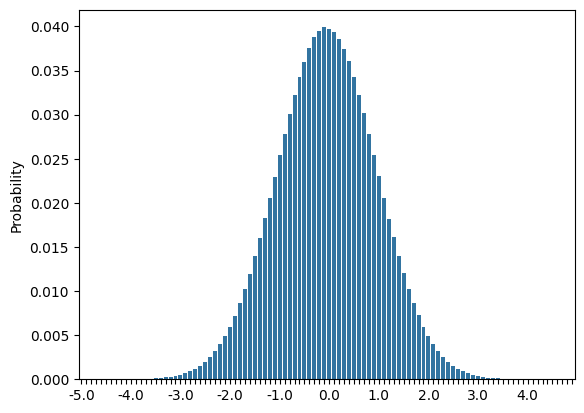

In [53]:
plot_continuous(
    sample_normal(n=10000000), plt.gca(), min_val=-5, max_val=5, label_precision=2
)

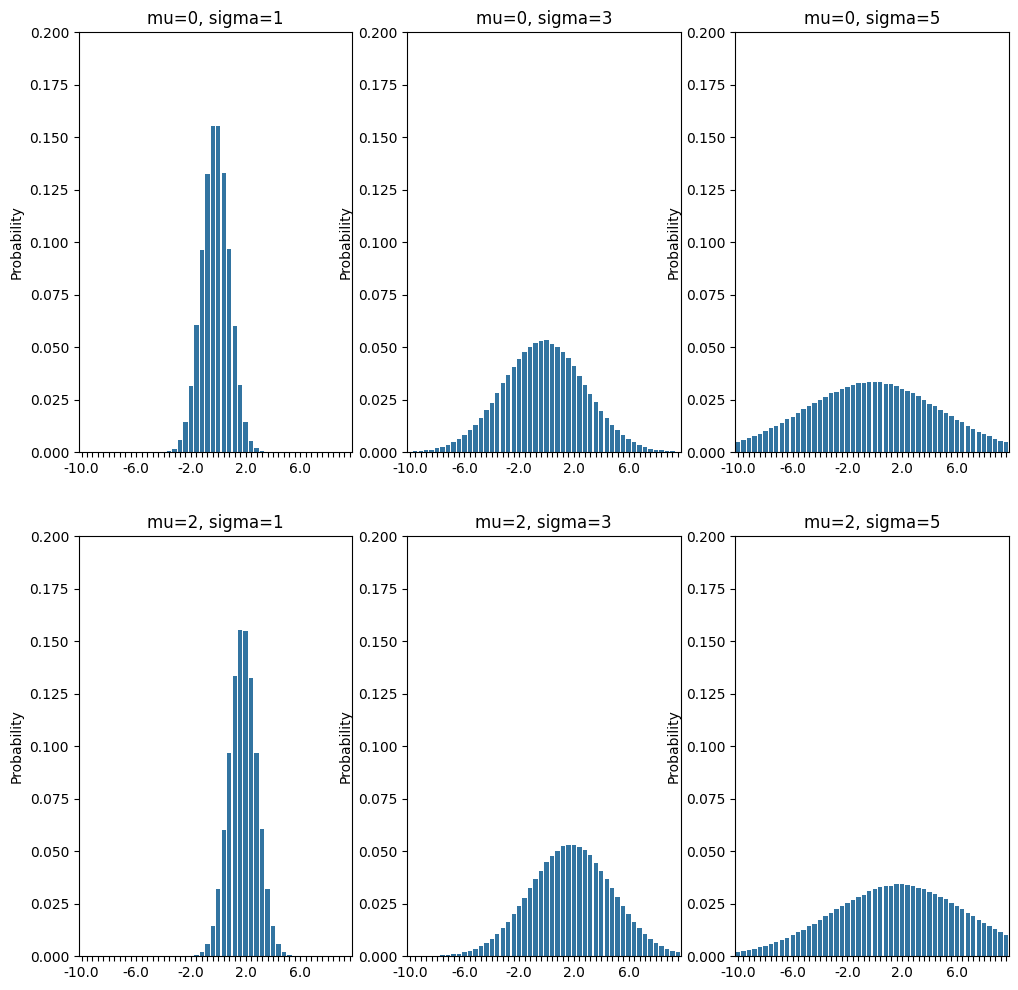

In [54]:
# make 9 small multiples with different mu and sigma values for the normal distribution
fig, axs = plt.subplots(2, 3, figsize=(12, 12))
for i, mu in enumerate([0, 2]):
    for j, sigma in enumerate([1, 3, 5]):
        plot_continuous(
            sample_normal(mu=mu, sigma=sigma, n=1000000),
            axs[i, j],
            min_val=-10,
            max_val=10,
            max_prob=0.2,
            num_bins=50,
            label_precision=1,
        )
        axs[i, j].set_title(f"mu={mu}, sigma={sigma}")

In [ ]:
# Exponential distribution¶

# The exponential distribution is a continuous probability distribution that describes the time between events in a Poisson process. 
# e.g. how long does it take before a light bulb goes out?
# It is defined by a single parameter, lambda (λ), which is the rate parameter. The rate parameter describes the number of events that occur in a unit of time.
# e.g. How likely does it take for a 5000 hr for a light bulb to go out?

def sample_exponential(lam=1, n=1000):
    return pd.DataFrame({"outcome": np.random.exponential(scale=1 / lam, size=n)})


In [56]:
sample_exponential(n=20)

,outcome
0,0.126091
1,1.331298
2,1.622597
3,1.829794
4,0.695289
5,0.737438
6,1.434933
7,1.499100
8,0.337504
9,0.021801


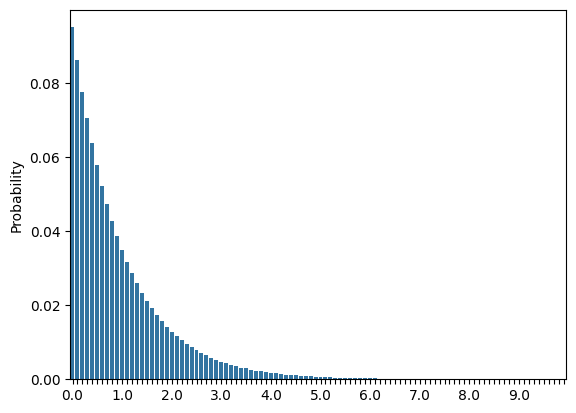

In [57]:
plot_continuous(
    sample_exponential(lam=1, n=10000000),
    plt.gca(),
    min_val=0,
    max_val=10,
    label_precision=1,
)

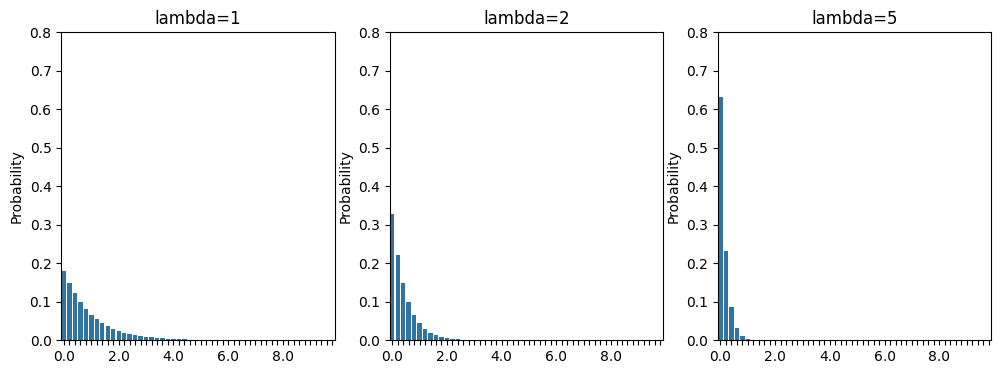

In [58]:
# 3 small multiples with lambda values of 1, 2, and 5
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for i, lam in enumerate([1, 2, 5]):
    plot_continuous(
        sample_exponential(lam=lam, n=1000000),
        axs[i],
        min_val=0,
        max_val=10,
        max_prob=0.8,
        num_bins=50,
        label_precision=1,
    )
    axs[i].set_title(f"lambda={lam}")